In [1]:
import tensorflow as tf

In [2]:
import matplotlib.pyplot as plt

In [3]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


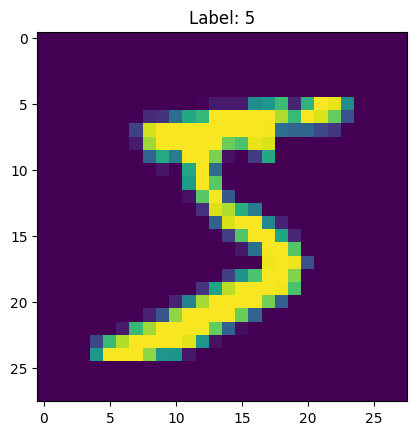

In [4]:
plt.figure()
plt.imshow(x_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10),
])

2026-03-19 21:31:49.175177: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5 Max
2026-03-19 21:31:49.175193: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-03-19 21:31:49.175197: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
2026-03-19 21:31:49.175210: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-19 21:31:49.175217: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

predictions = tf.nn.softmax(model(x_train[:1])).numpy()
print(predictions)
print(y_train[:1])
print(loss_fn(y_train[:1], predictions).numpy())

[[0.10881313 0.10496535 0.11337821 0.12073906 0.10937877 0.07030958
  0.1131795  0.0569853  0.12166393 0.08058721]]
[5]
2.3325016


In [7]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [14]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8814 - loss: 0.4280
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8826 - loss: 0.4323
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8816 - loss: 0.4433
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8760 - loss: 0.4593
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8763 - loss: 0.4702


In [9]:
model.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 3ms/step - accuracy: 0.9118 - loss: 0.3161


[0.3160579204559326, 0.9118000268936157]

In [10]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

In [11]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[4.67415946e-03, 5.31138949e-06, 9.94379073e-02, 1.94284711e-02,
        2.32554943e-04, 2.00158241e-03, 1.15664088e-05, 8.70715737e-01,
        1.09206489e-03, 2.40058452e-03],
       [3.09812895e-05, 5.69183576e-05, 9.95627165e-01, 3.03745409e-03,
        1.05678374e-07, 6.63719431e-04, 1.42700992e-05, 1.26259225e-10,
        5.69322554e-04, 7.37401917e-09],
       [3.33616154e-05, 9.68692541e-01, 2.40164343e-03, 2.61396082e-04,
        2.89710099e-03, 2.54691753e-04, 8.53551261e-04, 2.28268467e-02,
        3.64645966e-04, 1.41417794e-03],
       [9.06962514e-01, 6.09334493e-05, 5.45104640e-03, 2.64705770e-04,
        3.76416254e-03, 1.28264434e-03, 3.31177306e-03, 6.75872788e-02,
        3.06449190e-04, 1.10086072e-02],
       [6.41285897e-06, 3.08939320e-06, 4.19770979e-04, 1.01499118e-05,
        9.83110070e-01, 4.10509470e-04, 9.48609522e-05, 6.39630714e-04,
        2.75351340e-04, 1.50301969e-02]], dtype=float32)>

In [12]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [13]:
tf

<module 'tensorflow' from '/Users/dyoo/work/mlcc/.venv/lib/python3.12/site-packages/tensorflow/__init__.py'>